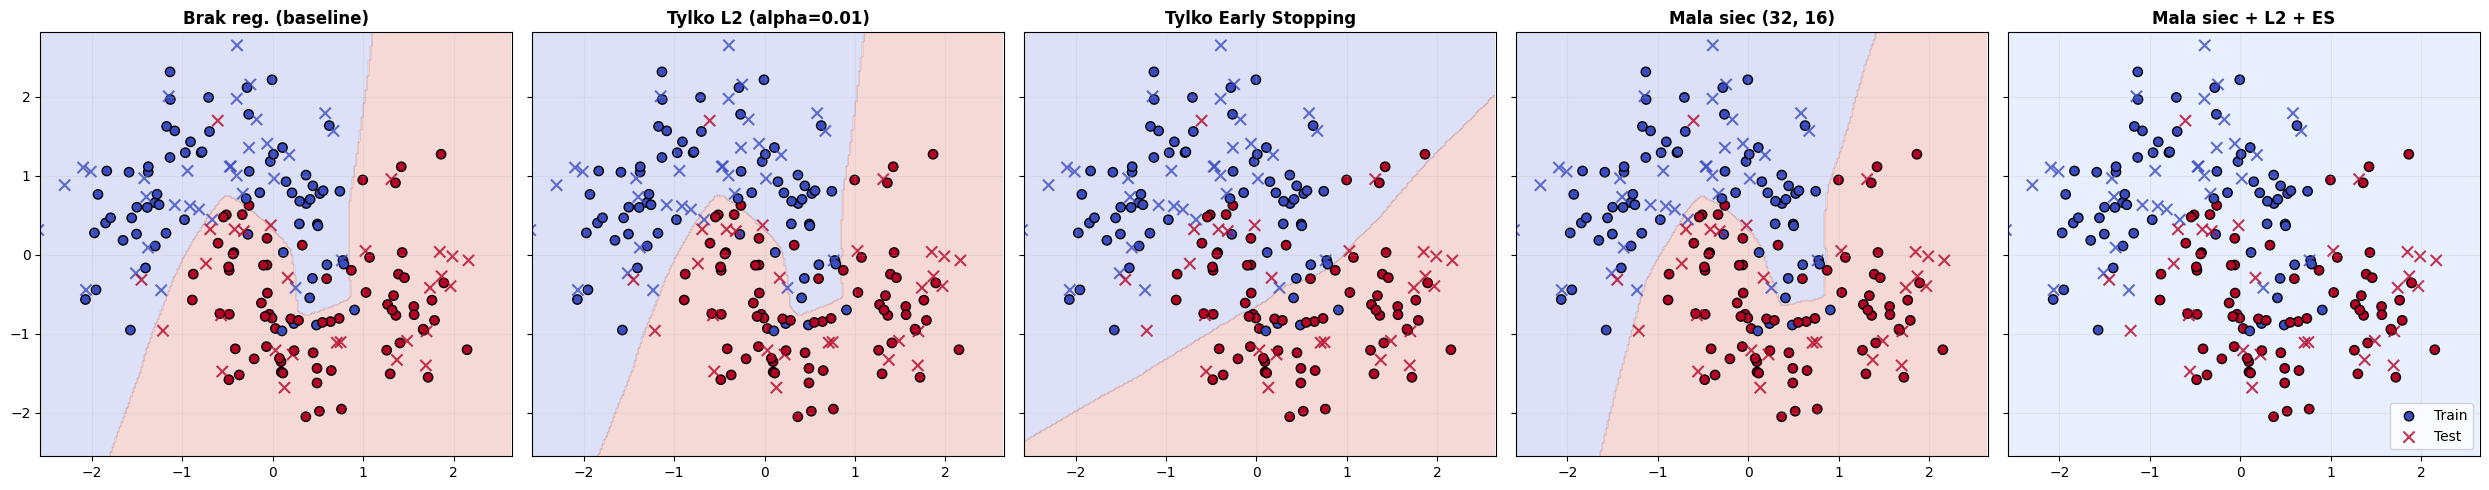


TABELA PORÓWNAWCZA WYNIKÓW:
Technika zapobiegania overfitting Train Accuracy Test Accuracy Gap (Train - Test)
             Brak reg. (baseline)          0.936         0.917              0.019
            Tylko L2 (alpha=0.01)          0.936         0.917              0.019
             Tylko Early Stopping          0.800         0.817             -0.017
               Mala siec (32, 16)          0.936         0.917              0.019
              Mala siec + L2 + ES          0.486         0.533             -0.048


In [8]:
# Porownaj 5 technik zapobiegania overfitting na make_moons.
# Wymagania:
# Techniki: (1) brak reg., (2) L2 alpha=0.01, (3) mala siec, (4) early stopping, (5) L2 + ES
# + mala siec
# n_samples=200, noise=0.3
# Narysuj granice decyzyjne (subplots 1x5)
# Tabela: train/test accuracy i gap
# Oczekiwany wynik:
# 5 wykresow i tabela porownawcza

import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Generowanie danych
X, y = make_moons(n_samples=200, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

configs_green = {
    'Brak reg. (baseline)': MLPClassifier(
        hidden_layer_sizes=(128, 64), alpha=0.0,
        max_iter=1000, random_state=42
    ),
    'Tylko L2 (alpha=0.01)': MLPClassifier(
        hidden_layer_sizes=(128, 64), alpha=0.01,
        max_iter=1000, random_state=42
    ),
    'Tylko Early Stopping': MLPClassifier(
        hidden_layer_sizes=(128, 64), alpha=0.0,
        max_iter=1000, random_state=42,
        early_stopping=True, validation_fraction=0.2, n_iter_no_change=10
    ),
    'Mala siec (32, 16)': MLPClassifier(
        hidden_layer_sizes=(32, 16), alpha=0.0,
        max_iter=1000, random_state=42
    ),
    'Mala siec + L2 + ES': MLPClassifier(
        hidden_layer_sizes=(32, 16), alpha=0.01,  # Zmieniono z 0.001 na 0.01 dla spójności
        max_iter=1000, random_state=42,
        early_stopping=True, validation_fraction=0.2, n_iter_no_change=10
    ),
}

# Przygotowanie siatki
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

results = []

# Konfiguracja subplots
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)

for ax, (name, clf) in zip(axes, configs_green.items()):
    clf.fit(X_train_scaled, y_train)
    
    train_acc = clf.score(X_train_scaled, y_train)
    test_acc = clf.score(X_test_scaled, y_test)
    gap = train_acc - test_acc
    
    results.append({
        'Technika zapobiegania overfitting': name,
        'Train Accuracy': f"{train_acc:.3f}",
        'Test Accuracy': f"{test_acc:.3f}",
        'Gap (Train - Test)': f"{gap:.3f}"
    })
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
    
    # Rysowanie punktów
    ax.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, 
               cmap='coolwarm', edgecolors='k', s=45, label='Train')
    ax.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, 
               cmap='coolwarm', marker='x', s=65, alpha=0.8, label='Test')
    
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, alpha=0.2)  # Dodano delikatną siatkę dla lepszej orientacji

# POPRAWKA: Dodanie legendy na ostatnim wykresie
axes[-1].legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

df_results = pd.DataFrame(results)
print("\nTABELA PORÓWNAWCZA WYNIKÓW:")
print(df_results.to_string(index=False))

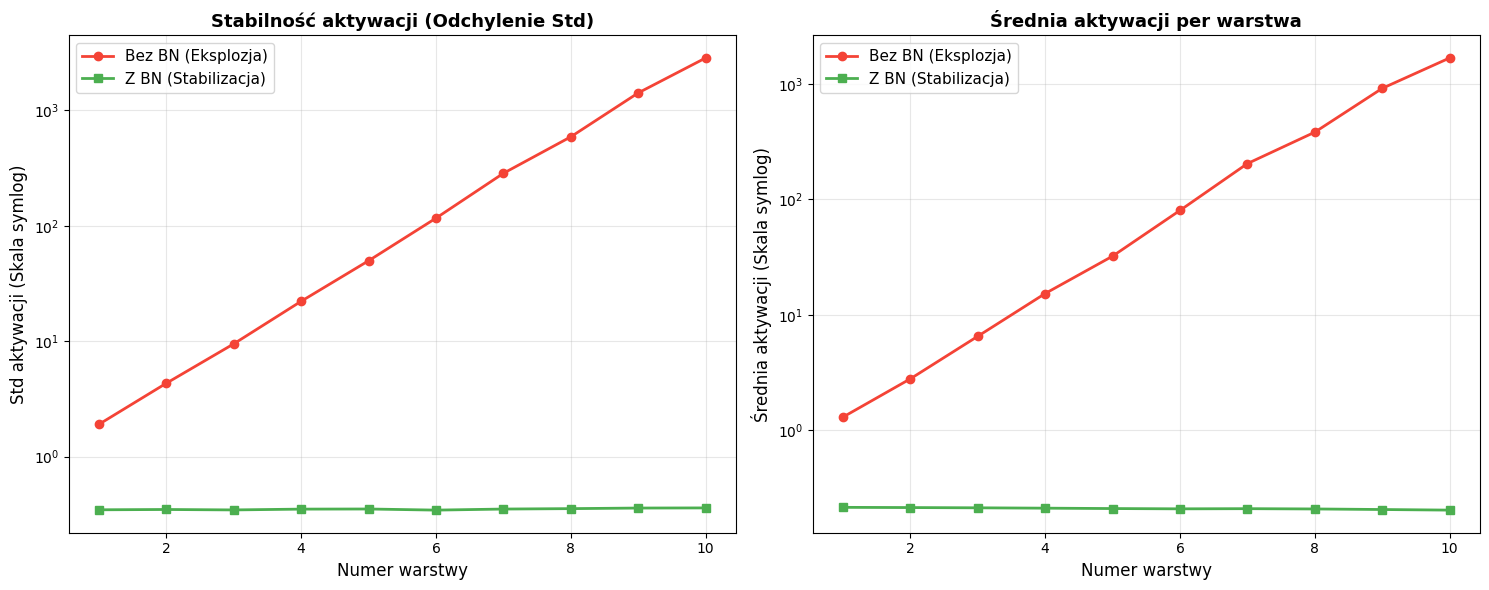

In [7]:
# Zbadaj jak BN stabilizuje propagacje sygnalu.
# Wymagania:
# Siec: 10 warstw, 64 neurony, ReLU
# Propaguj 256 losowych probek przez siec
# Wariant 1: bez BN, Wariant 2: z BN
# Zapisz mean i std aktywacji per warstwa
# Narysuj 2 wykresy: std vs warstwa (z/bez BN)
# Oczekiwany wynik:
# 2 wykresy porownawcze stabilnosci


import numpy as np
import matplotlib.pyplot as plt

# Batch Normalization 
class BatchNorm:
    """Batch Normalization: normalizuje aktywacje per mini-batch."""
    def __init__(self, n_features, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        # Uczone parametry
        self.gamma = np.ones((1, n_features)) # skala
        self.beta = np.zeros((1, n_features)) # przesuniecie
        # Srednia ruchoma do predykcji
        self.running_mean = np.zeros((1, n_features))
        self.running_var = np.ones((1, n_features))
        
    def forward(self, X, training=True):
        if training:
            # Oblicz statystyki per mini-batch
            self.batch_mean = X.mean(axis=0, keepdims=True)
            self.batch_var = X.var(axis=0, keepdims=True)
            # Normalizacja
            self.X_norm = (X - self.batch_mean) / np.sqrt(self.batch_var + self.eps)
            
            # Aktualizacja średnich kroczących
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * self.batch_mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * self.batch_var
        else:
            self.X_norm = (X - self.running_mean) / np.sqrt(self.running_var + self.eps)
            
        # Skalowanie, przesunięcie i obligatoryjny RETURN
        return self.gamma * self.X_norm + self.beta

n_layers = 10
n_neurons = 64
n_samples = 256

def propagate_layers(n_layers, use_batchnorm=False):
    """Symulacja forward pass przez wiele warstw."""
    # Losowy sygnał wejściowy
    x = np.random.randn(n_samples, n_neurons)
    means = []
    stds = []
    
    for layer in range(n_layers):
        # Mnożnik 0.4 przy 64 neuronach powoduje eksplozję wariancji (64 * 0.4^2 = 10.24)
        W = np.random.randn(n_neurons, n_neurons) * 0.4
        x = x @ W
        
        if use_batchnorm:
            # Batch Normalization przechwytuje i resetuje eksplodujący sygnał
            bn = BatchNorm(n_neurons)
            x = bn.forward(x, training=True)
            
        x = np.maximum(0, x) # Funkcja aktywacji ReLU
        
        means.append(x.mean())
        stds.append(x.std())
        
    return means, stds

# Uruchomienie eksperymentu
np.random.seed(42)
means_no_bn, stds_no_bn = propagate_layers(n_layers, use_batchnorm=False)
means_bn, stds_bn = propagate_layers(n_layers, use_batchnorm=True)

# Wizualizacja wyników - ZASTOSOWANIE SKALI SYMLOG
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Wykres 1: Odchylenie standardowe (Std)
ax1.plot(range(1, n_layers + 1), stds_no_bn, 'o-', color='#F44336', linewidth=2, label='Bez BN (Eksplozja)')
ax1.plot(range(1, n_layers + 1), stds_bn, 's-', color='#4CAF50', linewidth=2, label='Z BN (Stabilizacja)')
ax1.set_xlabel('Numer warstwy', fontsize=12)
ax1.set_ylabel('Std aktywacji (Skala symlog)', fontsize=12)
ax1.set_title('Stabilność aktywacji (Odchylenie Std)', fontsize=13, fontweight='bold')

# Przełączenie na skalę symlog
ax1.set_yscale('symlog', linthresh=1.0) 
ax1.legend(fontsize=11)
ax1.grid(True, which="both", alpha=0.3)

# Wykres 2: Średnia (Mean)
ax2.plot(range(1, n_layers + 1), means_no_bn, 'o-', color='#F44336', linewidth=2, label='Bez BN (Eksplozja)')
ax2.plot(range(1, n_layers + 1), means_bn, 's-', color='#4CAF50', linewidth=2, label='Z BN (Stabilizacja)')
ax2.set_xlabel('Numer warstwy', fontsize=12)
ax2.set_ylabel('Średnia aktywacji (Skala symlog)', fontsize=12)
ax2.set_title('Średnia aktywacji per warstwa', fontsize=13, fontweight='bold')

# Przełączenie na skalę symlog
ax2.set_yscale('symlog', linthresh=1.0) 
ax2.legend(fontsize=11)
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()